# CDC — current despair & immiseration data

The catalog's first-curated tables — `w9j2-ggv5` (life expectancy) and
`9j2v-jamp` (suicide) — are the deep-history *Health, United States 2019*
tables, and they **end at 2018**. This notebook looks at the **current** sources
found to close that gap, before we curate them:

- **Suicide** — `w26f-tf3h` (annual 2018–2024) + `489q-934x` (quarterly 2023–2025)
- **Life expectancy** — per-year state snapshots 2018–2021 (national via a `United
  States` row, 2018–2020 only; the 2021 snapshot is states-only)
- **The aligned despair triad** — `489q-934x` carries suicide + overdose +
  chronic-liver-disease together, quarterly — the only place they're contemporaneous

No server changes are needed: these all read through the generic `cdc_series_data`
tool. The MCP server must be running (`python mcp_server/server.py`).

In [1]:
%reload_ext autoreload
%autoreload 2

import sys
from datetime import datetime

import numpy
from matplotlib import pyplot
from lib import config

sys.path.append('../')

from utils import (
    show_columns,
    get_rows,
    cdc_rows_to_arrays,
    plot_cdc_series,
    plot_cdc_series_by,
)
from lib.plots import comparison

pyplot.style.use(config.glyfish_style)

## Suicide — current national rate (2018–2024)

`w26f-tf3h` is the successor to the retired `9j2v-jamp`. Note `group` is a SoQL
reserved word, so it must be back-tick quoted in the `where` clause.

In [ ]:
show_columns_out = await show_columns("w26f-tf3h")

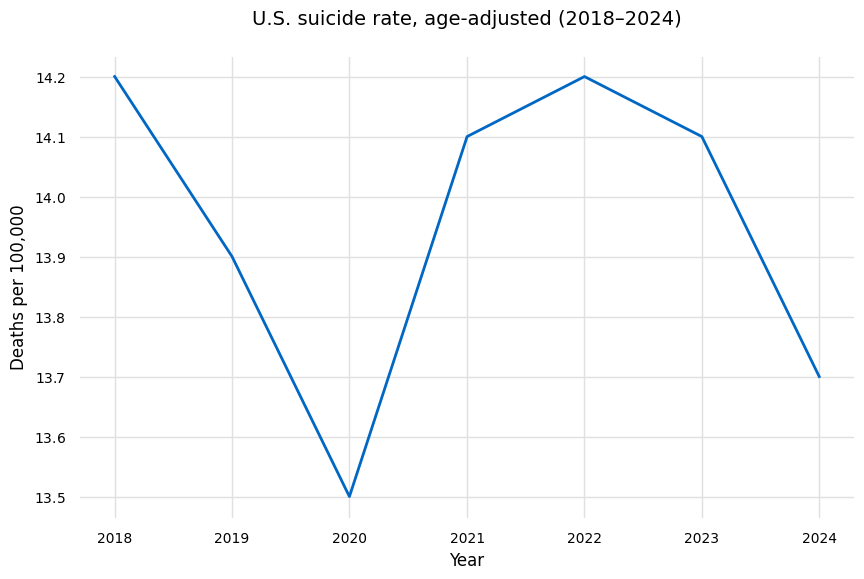

In [2]:
rows = await get_rows(
    "w26f-tf3h",
    where="`group`='Total' AND estimate_type='Deaths per 100,000 resident population, age adjusted'",
    order="time_period",
)
plot_cdc_series(
    rows, "time_period", "estimate",
    title="U.S. suicide rate, age-adjusted (2018–2024)",
    ylabel="Deaths per 100,000",
)

### Broken out by sex and by race / Hispanic origin

In [ ]:
rows = await get_rows(
    "w26f-tf3h",
    where="`group`='Sex' AND estimate_type='Deaths per 100,000 resident population, age adjusted'",
    order="time_period",
)
plot_cdc_series_by(
    rows, "time_period", "estimate", "subgroup", exclude=(),
    title="U.S. suicide rate by sex (2018–2024)",
    ylabel="Deaths per 100,000", legend_title="Sex",
)

In [ ]:
rows = await get_rows(
    "w26f-tf3h",
    where="`group`='Race and Hispanic origin' AND estimate_type='Deaths per 100,000 resident population, age adjusted'",
    order="time_period",
)
plot_cdc_series_by(
    rows, "time_period", "estimate", "subgroup", exclude=(),
    title="U.S. suicide rate by race & Hispanic origin (2018–2024)",
    ylabel="Deaths per 100,000", legend_title="Race / Hispanic origin",
)

## Suicide — the long arc: history + current, stitched

The historical `9j2v-jamp` (1950–2018) and current `w26f-tf3h` (2018–2024) report
the **same** 2018 age-adjusted value (14.2), so the two series meet seamlessly —
this is exactly the "deep history + current" pairing the catalog will curate.

In [ ]:
hist = await get_rows(
    "9j2v-jamp",
    where="stub_name='Total' AND unit='Deaths per 100,000 resident population, age-adjusted'",
    order="year",
)
cur = await get_rows(
    "w26f-tf3h",
    where="`group`='Total' AND estimate_type='Deaths per 100,000 resident population, age adjusted'",
    order="time_period",
)
hist_y, hist_x = cdc_rows_to_arrays(hist, "year", "estimate")
cur_y, cur_x = cdc_rows_to_arrays(cur, "time_period", "estimate")
comparison(
    [hist_y, cur_y], [hist_x, cur_x],
    labels=["Health US (1950–2018)", "DQS (2018–2024)"],
    title="U.S. suicide rate, age-adjusted — historical + current",
    xlabel="Year", ylabel="Deaths per 100,000", legend_title="Source",
)

## Life expectancy — the full arc, 1900–2020

All available national data in one line: the deep-history table `w9j2-ggv5` (All
Races / Both Sexes, 1900–2018) extended with the snapshot `United States` rows for
2019–2020. The 1918 influenza pandemic cuts life expectancy to **39.1 years**; it
climbs to a peak of **78.9 (2014)**, then the **2020 COVID drop** (78.8 → 77.0).

In [ ]:
from lib.plots import curve

arc = [
    {"year": r["year"], "le": r["average_life_expectancy"]}
    for r in await get_rows("w9j2-ggv5", where="race='All Races' AND sex='Both Sexes'", order="year")
    if r.get("average_life_expectancy")
]
# extend past 2018 with the snapshot United States rows (2019-2020)
for year, dataset_id, value_field in [("2019", "ncvk-7amm", "leb"), ("2020", "ss2j-8ajj", "le")]:
    for row in await get_rows(dataset_id, where="sex='Total'", limit=500):
        if str(row.get("state", "")).lower() == "united states":
            arc.append({"year": year, "le": row[value_field]})

le_y, le_x = cdc_rows_to_arrays(arc, "year", "le")
curve(
    le_y, le_x,
    title="U.S. life expectancy at birth, 1900–2020",
    xlabel="Year", ylabel="Years",
)

### Recent detail — the COVID drop, by state (2018–2021)

Recent life expectancy is published as **four separate single-year datasets**
with inconsistent field names (`leb` vs `le`, `state` vs `area`). We stitch them
into one table with a year column. The `United States` row exists only for
2018–2020, so the national line stops at 2020; state lines run through 2021.

In [ ]:
# (year -> dataset_id, geography field, value field) -- fields differ per year
LE_SNAPSHOTS = {
    "2018": ("a5a8-jsrq", "state", "leb"),
    "2019": ("ncvk-7amm", "state", "leb"),
    "2020": ("ss2j-8ajj", "state", "le"),
    "2021": ("it4f-frdc", "area",  "leb"),
}


async def load_life_expectancy():
    """Stitch the per-year state snapshots into one year-stamped table."""
    out = []
    for year, (dataset_id, geo_field, value_field) in LE_SNAPSHOTS.items():
        for row in await get_rows(dataset_id, limit=500):
            out.append({
                "year": year,
                "area": row.get(geo_field),
                "sex": row.get("sex"),
                "leb": row.get(value_field),
            })
    return out


life = await load_life_expectancy()

national = [r for r in life if str(r["area"]).lower() == "united states" and r["sex"] == "Total"]
plot_cdc_series(
    national, "year", "leb",
    title="U.S. life expectancy at birth (2018–2020)",
    ylabel="Years",
)

In [ ]:
states = [
    r for r in life
    if r["area"] in ("Hawaii", "California", "West Virginia", "Mississippi")
    and r["sex"] == "Total"
]
plot_cdc_series_by(
    states, "year", "leb", "area", exclude=(),
    title="Life expectancy at birth, selected states (2018–2021)",
    ylabel="Years", legend_title="State",
)

## The aligned despair triad — VSRR quarterly (2023–2025)

`489q-934x` is the one dataset that carries **suicide + drug overdose +
chronic-liver-disease** together, contemporaneously, so the three despair legs
line up on one time axis. `year_and_quarter` (e.g. `2023 Q1`) needs a small
parser. Rates are the 12-months-ending-quarter, age-adjusted view.

In [ ]:
def quarter_to_date(label):
    """'2023 Q1' -> datetime(2023, 1, 1)."""
    year, quarter = label.split(" Q")
    return datetime(int(year), (int(quarter) - 1) * 3 + 1, 1)


CAUSES = ["Suicide", "Drug overdose", "Chronic liver disease and cirrhosis"]
causes_sql = ",".join("'%s'" % c for c in CAUSES)
rows = await get_rows(
    "489q-934x",
    where=(
        "rate_type='Age-adjusted' "
        "AND time_period='12 months ending with quarter' "
        "AND cause_of_death in(%s)" % causes_sql
    ),
    order="year_and_quarter",
)

ys, xs, labels = [], [], []
for cause in CAUSES:
    points = sorted(
        (quarter_to_date(r["year_and_quarter"]), float(r["rate_overall"]))
        for r in rows
        if r.get("cause_of_death") == cause and r.get("rate_overall")
    )
    if points:
        labels.append(cause)
        xs.append(numpy.array([p[0] for p in points]))
        ys.append(numpy.array([p[1] for p in points]))

comparison(
    ys, xs, labels=labels,
    title="Deaths of despair — aligned & current (VSRR, 12-mo-ending)",
    xlabel="Quarter", ylabel="Deaths per 100,000", legend_title="Cause",
)